# Plot ImageNet Debug Curves

This notebook loads the three `summary.csv` files under `files/debug/` for `DDPM-E`, `DDPM-V`, and the latest `Transport-V` `diff2flow` sweep, then plots FID versus the number of sampling steps. The final cell provides an optional zoom over the high-step regime.


In [3]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "axes.grid": False,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})
plt.rcParams["mathtext.fontset"] = "cm"


In [4]:
print('yes')

yes


In [ ]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

summary_paths = {
    "ddpm_e": repo_root / "files/debug/dff2flow/fid5k_plain_dit_psample_imagenet/summary.csv",
    "ddpm_v": repo_root / "files/debug/dff2flow/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv",
    "transport_v": repo_root / "files/debug/dff2flow/fid5k_dit_transport_velocity_diff2flow_steps/summary.csv",
}

for name, path in summary_paths.items():
    print(f"{name}: {path}")
    print("  exists:", path.exists())


ddpm_e: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_plain_dit_psample_imagenet/summary.csv
  exists: True
ddpm_v: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_plain_dit_native_velocity_data_imagenet/summary.csv
  exists: True
transport_v: /projets/Mdesbos/yara/imeanflow/files/debug/fid5k_dit_transport_velocity_diff2flow_steps/summary.csv
  exists: True


In [6]:
def load_summary(csv_path):
    rows = []
    with csv_path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                "num_steps": int(row["num_steps"]),
                "fid": float(row["fid"]),
            })
    return sorted(rows, key=lambda item: item["num_steps"])

series = {name: load_summary(path) for name, path in summary_paths.items()}
series

{'ddpm_e': [{'num_steps': 1, 'fid': 360.8994033721855},
  {'num_steps': 2, 'fid': 251.8281212010633},
  {'num_steps': 4, 'fid': 125.36909700893767},
  {'num_steps': 8, 'fid': 61.846818230265626},
  {'num_steps': 16, 'fid': 21.163585886186752},
  {'num_steps': 32, 'fid': 10.589438446915494},
  {'num_steps': 64, 'fid': 8.542726956715},
  {'num_steps': 250, 'fid': 8.14754348297214}],
 'ddpm_v': [{'num_steps': 1, 'fid': 249.94061254799757},
  {'num_steps': 2, 'fid': 156.58341798741066},
  {'num_steps': 4, 'fid': 77.84384469408133},
  {'num_steps': 8, 'fid': 19.996032179798306},
  {'num_steps': 16, 'fid': 9.44366091387576},
  {'num_steps': 32, 'fid': 8.010907122743845},
  {'num_steps': 64, 'fid': 7.695445289042368},
  {'num_steps': 250, 'fid': 7.656952387831723}],
 'transport_v': [{'num_steps': 1, 'fid': 247.86033394315407},
  {'num_steps': 2, 'fid': 160.77276519027106},
  {'num_steps': 4, 'fid': 43.51503824724392},
  {'num_steps': 8, 'fid': 14.294599308414263},
  {'num_steps': 16, 'fid': 8

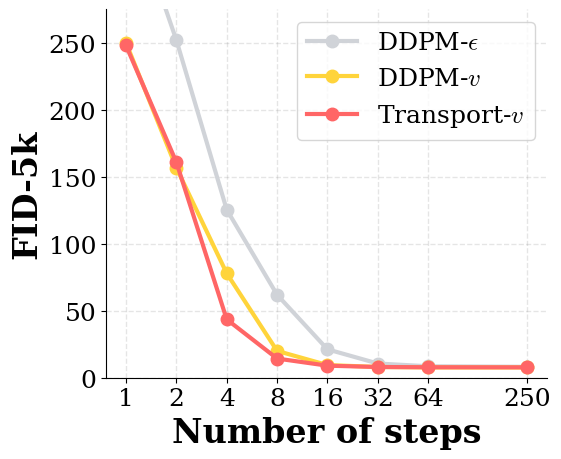

In [7]:
labels = {
    "ddpm_e": "DDPM-$\\epsilon$",
    "ddpm_v": "DDPM-$v$",
    "transport_v": "Transport-$v$",
}

plot_names = ["ddpm_e", "ddpm_v", "transport_v"]
plot_styles = {
    "ddpm_e": {"color": "#d0d3d8", "marker": "o"},
    "ddpm_v": {"color": "#ffd43b", "marker": "o"},
    "transport_v": {"color": "#ff6666", "marker": "o"},
}

fig, ax = plt.subplots(figsize=(6, 5))

for name in plot_names:
    rows = series[name]
    steps = [row["num_steps"] for row in rows]
    fid_values = [row["fid"] for row in rows]
    style = plot_styles[name]
    ax.plot(
        steps,
        fid_values,
        marker=style["marker"],
        markersize=9,
        linewidth=3,
        color=style["color"],
        label=labels[name],
    )

ax.set_xlabel("Number of steps", fontweight="bold")
ax.set_ylabel("FID-5k", fontweight="bold")
ax.set_xscale("log", base=2)
ax.set_ylim(0, 275)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 250])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend(frameon=True, fancybox=True)
ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=1.0,
    color="gray",
    alpha=0.2,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
# Optional: print the best FID from each plotted method
for name in plot_names:
    rows = series[name]
    best = min(rows, key=lambda row: row["fid"])
    print(f"{labels[name]}: best FID = {best['fid']:.4f} at {best['num_steps']} steps")


DDPM-$\epsilon$: best FID = 8.1475 at 250 steps
DDPM-$v$: best FID = 7.6570 at 250 steps
Transport-$v$: best FID = 7.7354 at 250 steps


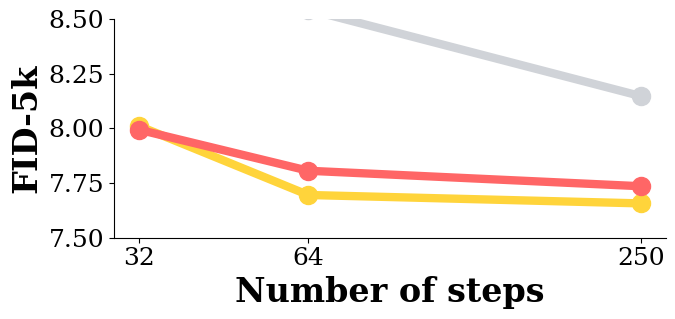

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))

for name in plot_names:
    rows = [row for row in series[name] if 32 <= row["num_steps"] <= 250]
    if not rows:
        continue

    steps = [row["num_steps"] for row in rows]
    fid_values = [row["fid"] for row in rows]
    style = plot_styles[name]
    ax.plot(
        steps,
        fid_values,
        marker=style["marker"],
        markersize=13,
        linewidth=6,
        color=style["color"],
        label=labels[name],
    )

ax.set_xlabel("Number of steps", fontweight="bold")
ax.set_ylabel("FID-5k", fontweight="bold")
ax.set_xscale("log", base=2)
ax.set_xticks([32, 64, 250])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(7.5, 8.5)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
